# BayesFlow: Personwise Model Parameter Estimation (Mammals)

Author:      David Izydorczyk 

In [1]:
import numpy as np
import numpy.random as rng


import matplotlib.pyplot as plt
import seaborn as sns


import os
if "KERAS_BACKEND" not in os.environ:
    # set this to "torch", "tensorflow", or "jax"
    os.environ["KERAS_BACKEND"] = "jax"

import keras
import bayesflow as bf
import pandas as pd
import statsmodels.formula.api as sm
import arviz as az



from plotnine import (
    theme_set,
    theme_bw
)
theme_set(theme_bw())


INFO:bayesflow:Using backend 'jax'
INFO:arviz.preview:arviz_base not installed
INFO:arviz.preview:arviz_stats not installed
INFO:arviz.preview:arviz_plots not installed


In [2]:
import utils.helper_functions as fn
import utils.model_functions as mf

# makes sure mf is loaded correctly
import importlib
importlib.reload(mf) 
importlib.reload(fn) 

<module 'utils.helper_functions' from 'c:\\Users\\dizydorc\\OneDrive\\University\\Project Github Repositories\\Estimation processes in real-world domains\\Scripts\\Parameter Estimation\\utils\\helper_functions.py'>

In [3]:
# avoid scientific notation for outputs
np.set_printoptions(suppress=True)

# 1 Load Design Data 

In [4]:
df = pd.read_csv('..\..\Materials\design_data_mammals.csv', sep=';',decimal=",")
df.head()

,ID,item,crit,img,training,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10
0,1,Aoudad,335,01.png,0,-0.567875,-0.015278,0.216645,-0.260836,-0.047524,-0.193240,0.043678,-0.002896,-0.120112,0.076603
1,2,Brazilian tapir,1095,02.png,0,-0.392465,0.184646,-0.071257,-0.027939,0.298438,-0.240948,-0.174659,-0.244244,0.003726,-0.023815
2,3,American bison,912,03.png,0,-0.553953,-0.067230,0.094129,-0.232337,0.206952,0.030337,0.129310,0.098340,-0.205172,0.202011
3,4,Giant anteater,1186,04.png,0,0.067508,0.169333,-0.082213,0.037893,0.284212,-0.473084,-0.060646,-0.019342,0.346182,-0.129704
4,5,Ibex,797,05.png,0,-0.557179,0.020041,0.214498,-0.259488,-0.106287,-0.071999,-0.062104,-0.004846,-0.196821,0.151096


In [5]:
all_cues = df[[f'dim_{i}' for i in range(1, 11)]].to_numpy(dtype=float)
all_crit = df[['crit']].to_numpy(dtype=float).flatten()

# Get Exemplar Set 
exemplars = df.loc[df['training'] == 1,:] 
ex_cues   = exemplars[[f'dim_{i}' for i in range(1, 11)]].to_numpy(dtype=float)
ex_crit   = exemplars[['crit']].to_numpy(dtype=float).flatten()
ex_IDs    = exemplars[["ID"]].to_numpy(dtype=float).squeeze().astype(int)

# Get Data from only Testing items
testing = df.loc[df['training'] == 0,:]

# Get the IDs
test_IDs = testing[["ID"]].to_numpy(dtype=float).squeeze().astype(int)

# Extract cues of the testing stimuli
cues     = testing[[f'dim_{i}' for i in range(1, 11)]].to_numpy(dtype=float)

# Make cue dictionary
dict_cues = {f"cue_{i}": cues[:, i] for i in range(cues.shape[1])}

# Geet number of trials and number of dimensions
n_trials, n_dim     = cues.shape

print("n_trials:", n_trials)
print("n_dim:"   , n_dim)

n_trials: 68
n_dim: 10


In [6]:
# Set general parameters
rate = 0.01

In [7]:
# Define positional encodings
position_encodings = np.linspace(0, 1, n_trials, dtype=np.float32)

# 2 Define Models

## 2.1 CAM - Cue Abstraction (Rule) Model 

In [9]:
# Run Regression on whole item samples
result = sm.ols(formula="crit ~ dim_1 + dim_2 + dim_3 + dim_4 + dim_5 + dim_6 + dim_7 + dim_8 + dim_9 + dim_10", data=df).fit()
# print(result.params)
# print(result.summary())

In [10]:
def prior_CAM(n_dim = n_dim, rate = rate):

    # Init weight parameters
    w = np.zeros(n_dim+1)

    # Intercept
    w[0]   = rng.normal(984.65, 300)

    # Dimension weights (Importance)
    w[1:]  = rng.normal(0, 750, size = n_dim)

    sigma  = rng.exponential(1/rate)

    return dict(w=w, sigma=sigma)

In [11]:
def model_CAM(w, sigma, cues=cues, p=position_encodings):

    n_trials, _   = cues.shape
  
    # Pre-allocate the output matrix
    pred_crit = mf.CAM_experiment(w,cues)

    # Simulate responses 
    x = fn.truncnorm_r(mean=pred_crit, sd=sigma, low=0, upp=10000, size=n_trials)
    
    return dict(x=x, p=p)  


In [12]:
simulator_CAM = bf.make_simulator([prior_CAM, model_CAM])

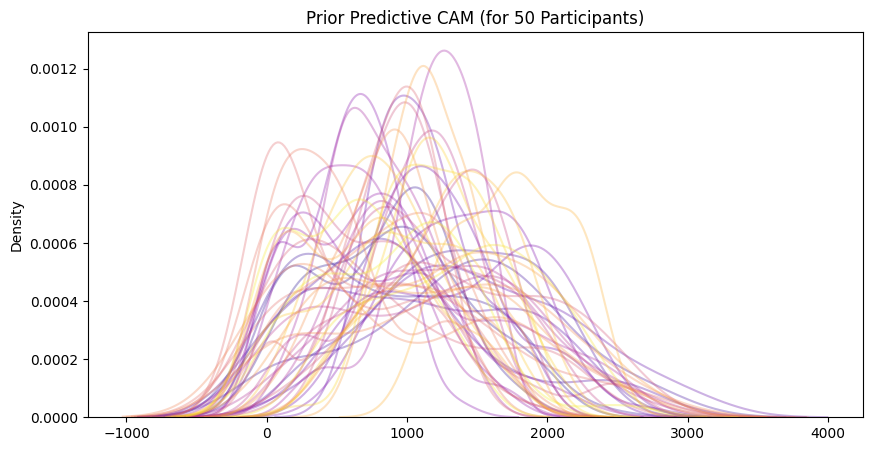

In [13]:
fig, ax = fn.plot_prior_predictives(simulator_CAM, "CAM")

### Estimation


In [14]:
adapter_CAM = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .constrain("sigma", lower=0)
    .as_time_series(["x","p"])
    .standardize()
    .concatenate(["w", "sigma"], into="inference_variables")
    .concatenate(["x", "p"], into="summary_variables")
)


summary_network   = bf.networks.SetTransformer(summary_dim=30)

inference_network = bf.networks.CouplingFlow()


workflow_CAM = bf.BasicWorkflow(
    simulator         = simulator_CAM,
    adapter           = adapter_CAM,
    summary_network   = summary_network,
    inference_network = inference_network,
)


In [15]:
# history = workflow_CAM.fit_online(epochs= 30, batch_size=32, num_batches_per_epoch=1000)

In [16]:
# Save model
# workflow_CAM.approximator.save("..\..\Results\Trained Networks\estimation_CAM_MAMMALS.keras")
workflow_CAM.approximator = keras.saving.load_model("..\..\Results\Trained Networks\estimation_CAM_MAMMALS.keras")

c:\Users\dizydorc\OneDrive\University\Project Github Repositories\Estimation processes in real-world domains\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 303 variables. 


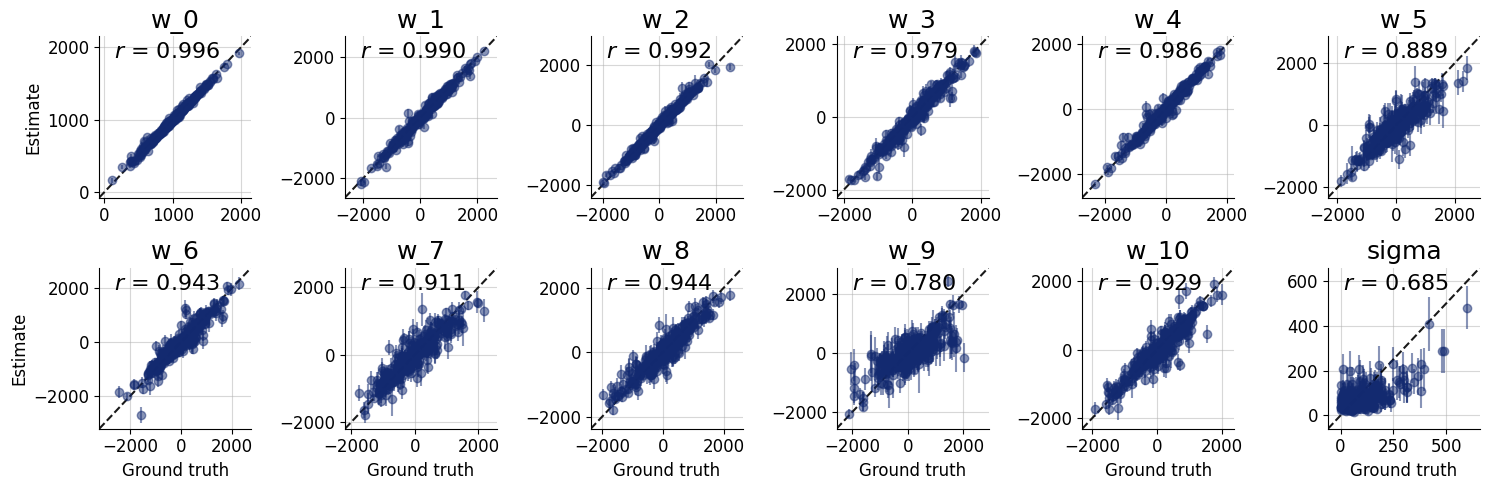

Error in callback <function flush_figures at 0x000001E07D60E840> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [61]:
figures = workflow_CAM.plot_default_diagnostics(
    test_data                  = 300,
    loss_kwargs                = {"figsize": (15, 5), "label_fontsize": 12},
    recovery_kwargs            = {"figsize": (15, 5), "label_fontsize": 12}    
)

## 2.2 GCM - Exemplar Model


In [18]:
def prior_GCM(n_dim = n_dim, rate = rate):

    c      = rng.exponential(1/0.1)
    w      = rng.dirichlet(np.ones(n_dim), size = 1) * n_dim
    sigma  = rng.exponential(1/rate)

    return dict(c=c, w=w.squeeze(), sigma=sigma)

In [19]:
def model_GCM(c, w, sigma, cues=cues, ex_cues=ex_cues, ex_crit=ex_crit, p=position_encodings):
  
    n_trials = cues.shape[0]

    # Make predictions based on the GCM model for all trials at once
    pred_crit = mf.GCM_experiment(cues, ex_cues, ex_crit, w, c)

    # Simulate responses
    x = fn.truncnorm_r(mean=pred_crit, sd=sigma, low=0, upp=10000, size=n_trials)

    return dict(x=x, p=p)

In [20]:
simulator_GCM = bf.make_simulator([prior_GCM, model_GCM])

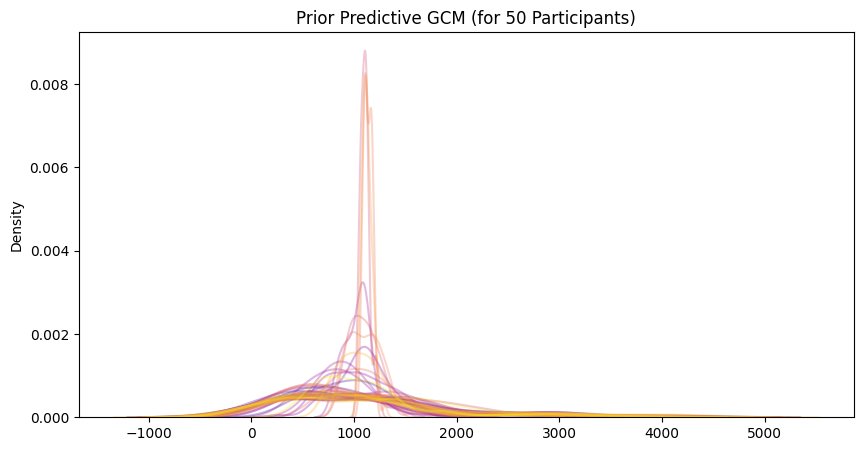

In [21]:
fig, ax = fn.plot_prior_predictives(simulator_GCM, "GCM")

### Estimation

In [22]:
adapter_GCM = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .as_time_series(["x","p"])
    .constrain("sigma", lower=0)
    .constrain("c", lower = 0)
    .constrain("w", lower = 0, upper = n_dim)
        
    .standardize()

    .concatenate(["c", "w", "sigma"], into="inference_variables")
    .concatenate(["x", "p"], into="summary_variables")

   
)

summary_network   = bf.networks.SetTransformer(summary_dim=35)

inference_network = bf.networks.CouplingFlow(subnet="mlp", transform="spline")


workflow_GCM = bf.BasicWorkflow(
    simulator         = simulator_GCM,
    adapter           = adapter_GCM,
    summary_network   = summary_network,
    inference_network = inference_network,
)


In [23]:
%%time
# history = workflow_GCM.fit_online(epochs=40, batch_size=64, num_batches_per_epoch=1000)

CPU times: total: 0 ns
Wall time: 0 ns


In [24]:
# Save model
# workflow_GCM.approximator.save("..\..\Results\Trained Networks\estimation_GCM_MAMMALS.keras")
workflow_GCM.approximator     = keras.saving.load_model("..\..\Results\Trained Networks\estimation_GCM_MAMMALS.keras")

c:\Users\dizydorc\OneDrive\University\Project Github Repositories\Estimation processes in real-world domains\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 303 variables. 


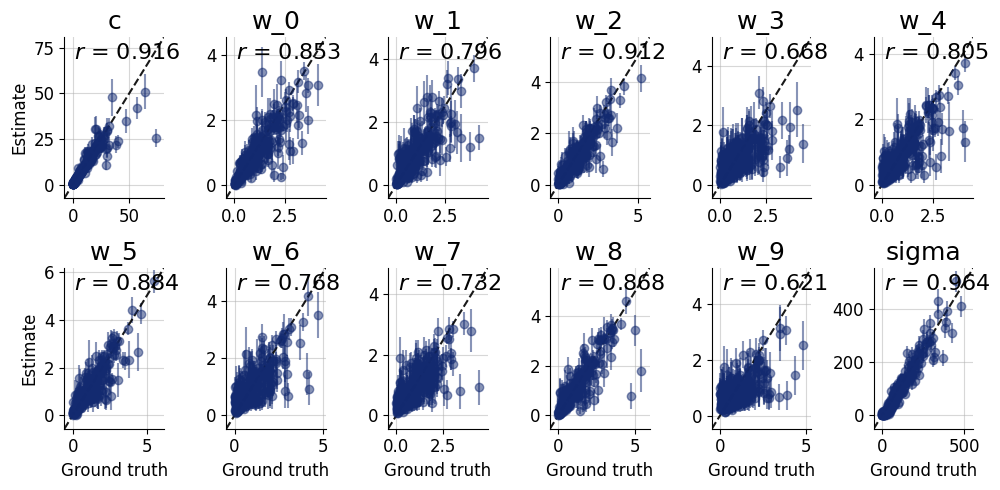

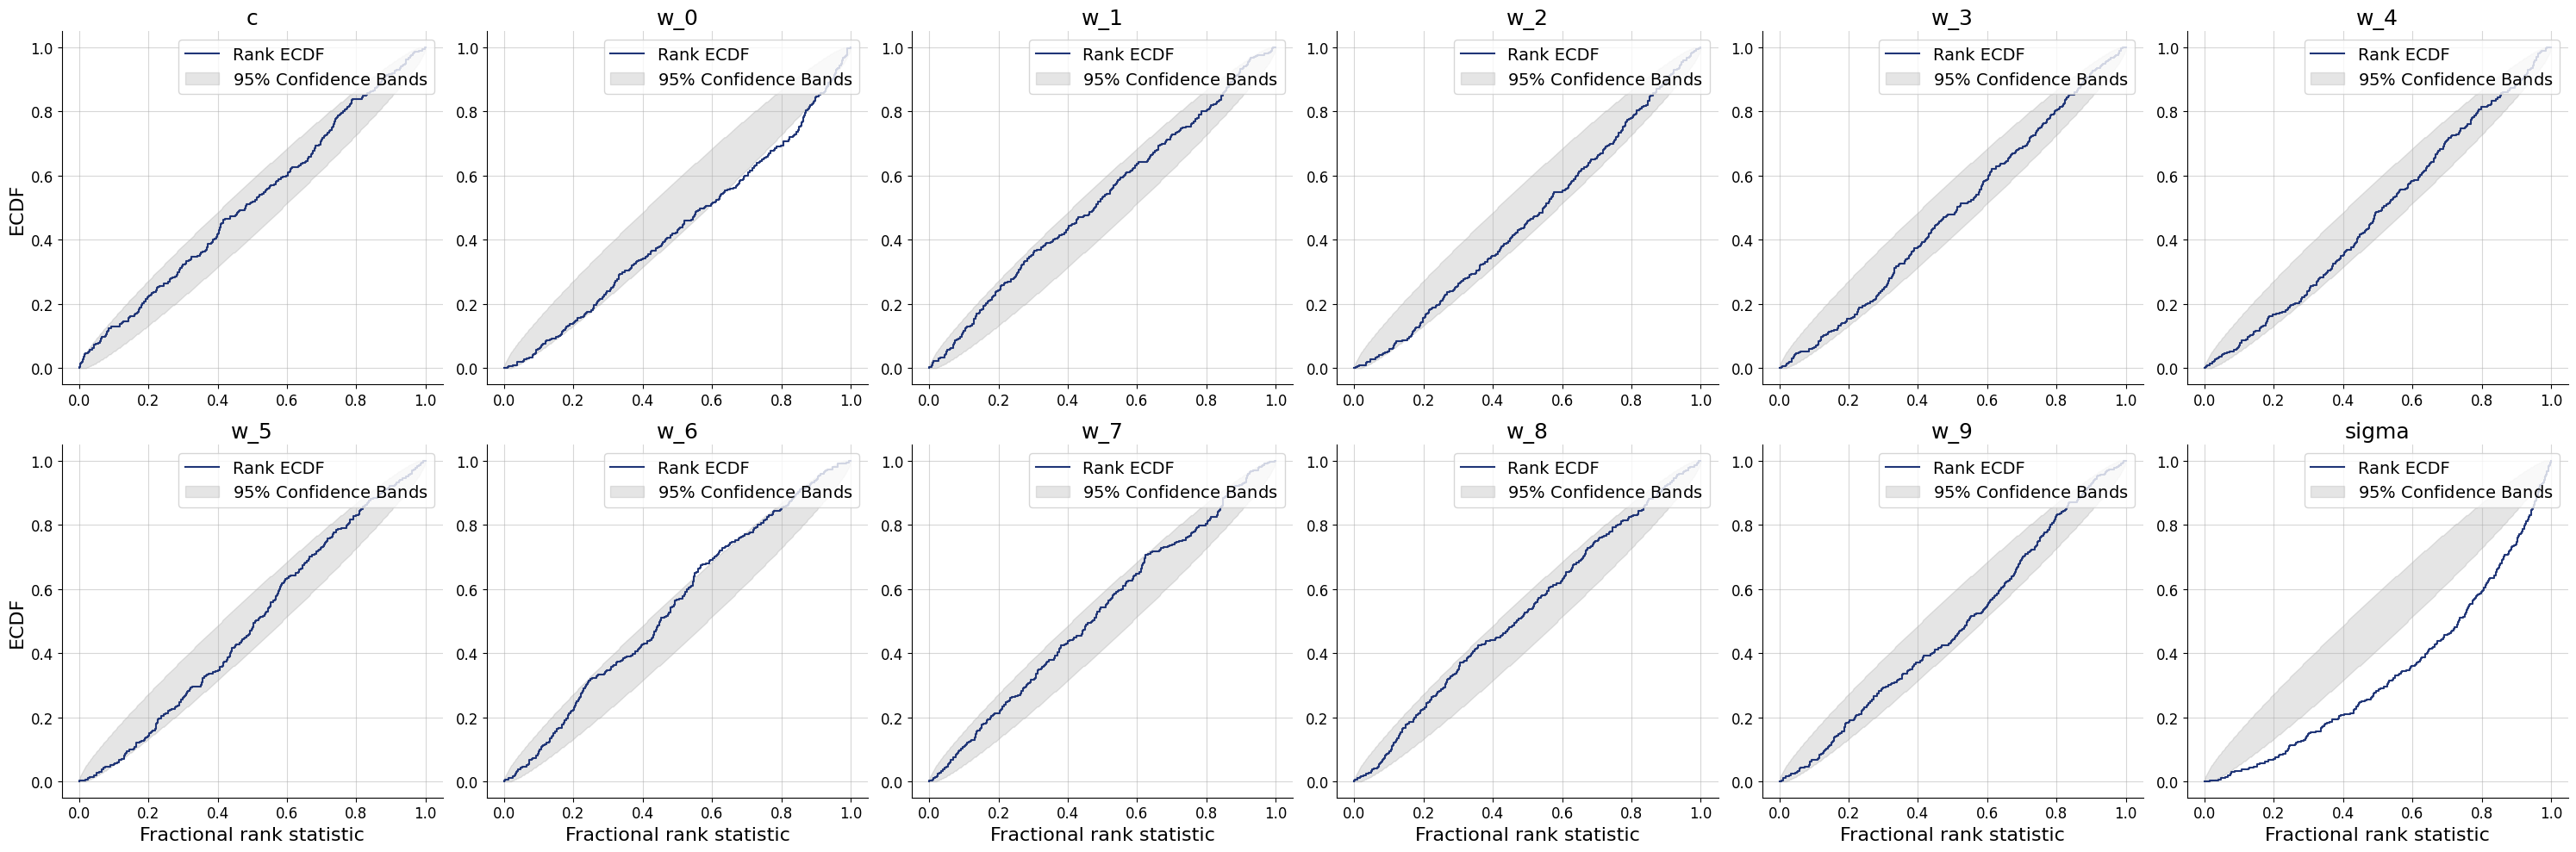

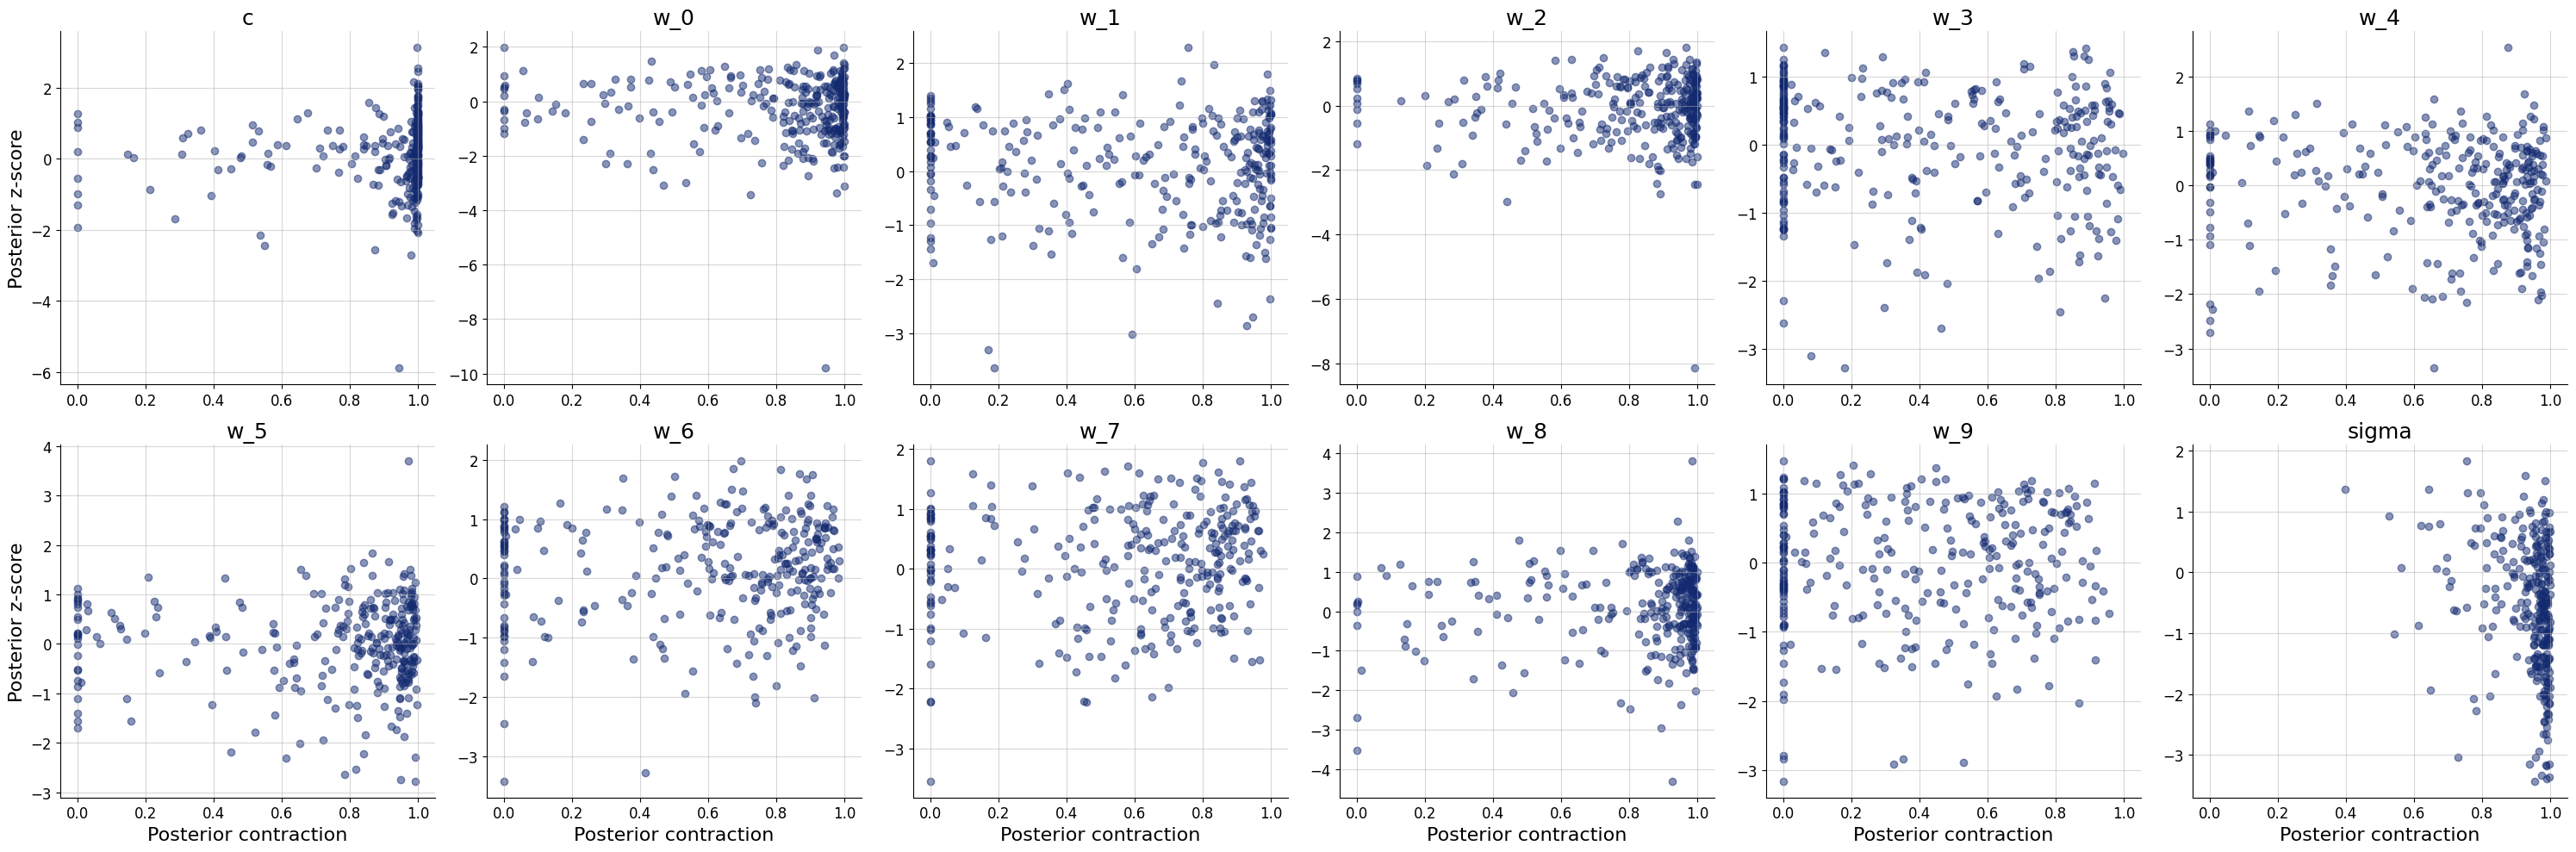

In [25]:
figures = workflow_GCM.plot_default_diagnostics(
    test_data                  = 300,
    loss_kwargs                = {"figsize": (7, 4), "label_fontsize": 12},
    recovery_kwargs            = {"figsize": (10, 5), "label_fontsize": 12}
)

## 2.3 RulExJ Model


In [26]:
def prior_RULEXJ(n_dim = n_dim, rate = rate):

    # Rule part
    CAM_pars = prior_CAM(n_dim = n_dim, rate = rate)

    # Exemplar part
    GCM_pars = prior_GCM(n_dim = n_dim, rate = rate)

    # Blending
    a        = rng.uniform(0,1)

    return dict(alpha = a, w_CAM=CAM_pars["w"], c = GCM_pars["c"], w_GCM = GCM_pars["w"], sigma=CAM_pars["sigma"])

In [27]:
def model_RULEXJ(alpha, w_CAM, c, w_GCM, sigma,  cues=cues, ex_cues=ex_cues, ex_crit=ex_crit, p=position_encodings):
    
    n_trials, _   = cues.shape
    
    pred_CAM = mf.CAM_experiment(w_CAM,cues)

    pred_GCM = mf.GCM_experiment(cues, ex_cues, ex_crit,w_GCM,c)

    pred_RULEXJ = alpha*pred_CAM + (1-alpha)*pred_GCM

    # Simulate responses 
    x = fn.truncnorm_r(mean=pred_RULEXJ, sd=sigma, low=0, upp=10000, size=n_trials)

    return dict(x=x, p=p)

In [28]:
simulator_RULEXJ = bf.make_simulator([prior_RULEXJ, model_RULEXJ])

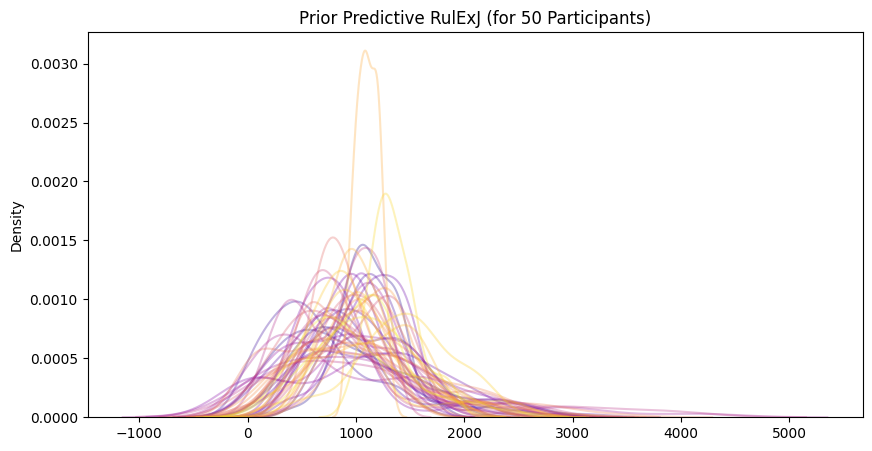

In [29]:
fig, ax = fn.plot_prior_predictives(simulator_RULEXJ, "RulExJ")

### Estimation


In [30]:
adapter_RULEXJ = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .as_time_series(["x","p"])

    .constrain("sigma", lower=0)
    .constrain("c", lower = 0)
    .constrain("w_GCM", lower = 0, upper = n_dim)
    .constrain("alpha", lower = 0, upper = 1)
    
    
    .standardize()

    .concatenate(["alpha","w_CAM","c", "w_GCM", "sigma"], into="inference_variables")
    .concatenate(["x", "p"], into="summary_variables")
)

summary_network   = bf.networks.TimeSeriesNetwork(summary_dim=40)

inference_network = bf.networks.CouplingFlow()


workflow_RULEXJ = bf.BasicWorkflow(
    simulator         = simulator_RULEXJ,
    adapter           = adapter_RULEXJ,
    summary_network   = summary_network,
    inference_network = inference_network,
)


In [31]:
%%time
# history = workflow_RULEXJ.fit_online(epochs=50, batch_size=64, num_batches_per_epoch=1000)

CPU times: total: 0 ns
Wall time: 0 ns


In [32]:
# Save model
# workflow_RULEXJ.approximator.save("..\..\Results\Trained Networks\estimation_RULEXJ_MAMMALS.keras")
workflow_RULEXJ.approximator     = keras.saving.load_model("..\..\Results\Trained Networks\estimation_RULEXJ_MAMMALS.keras")

c:\Users\dizydorc\OneDrive\University\Project Github Repositories\Estimation processes in real-world domains\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 205 variables. 


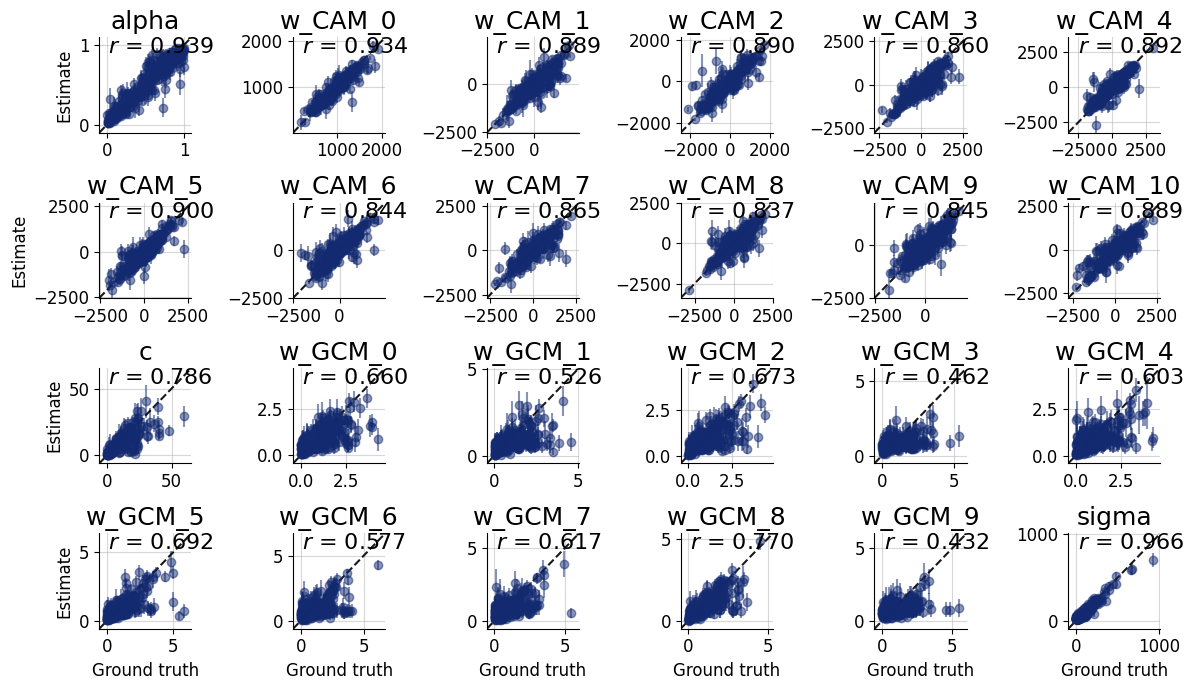

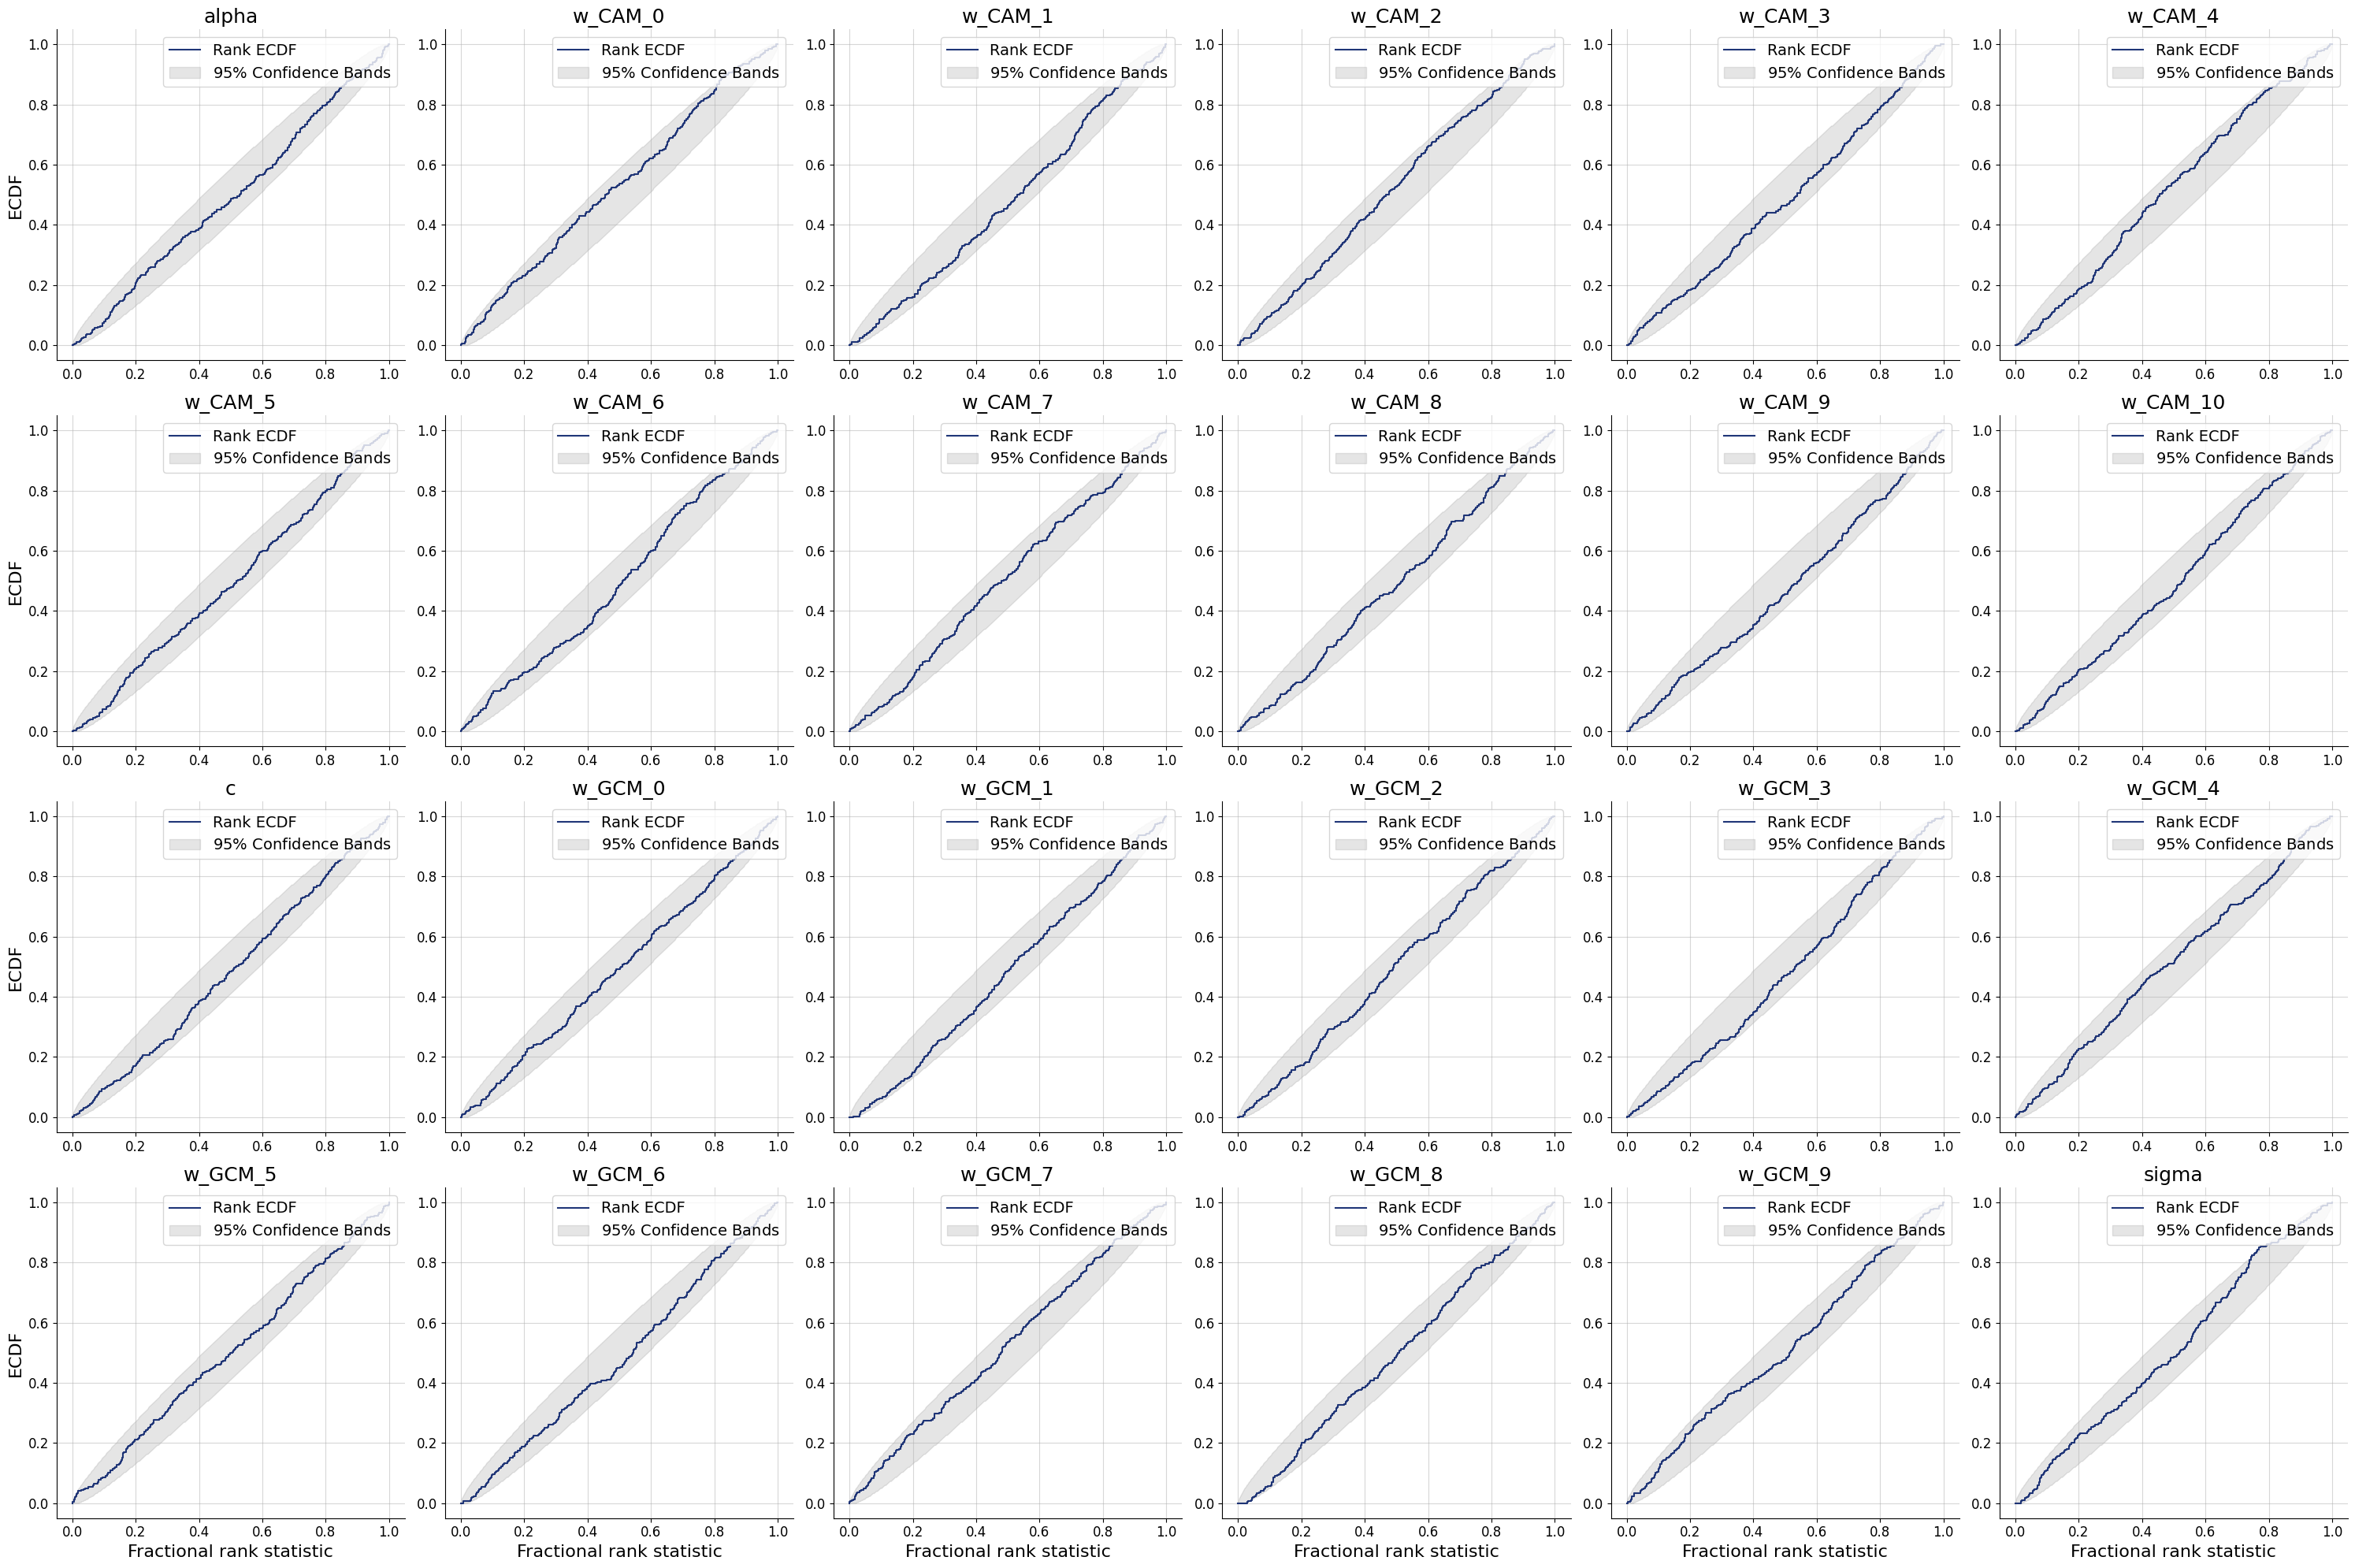

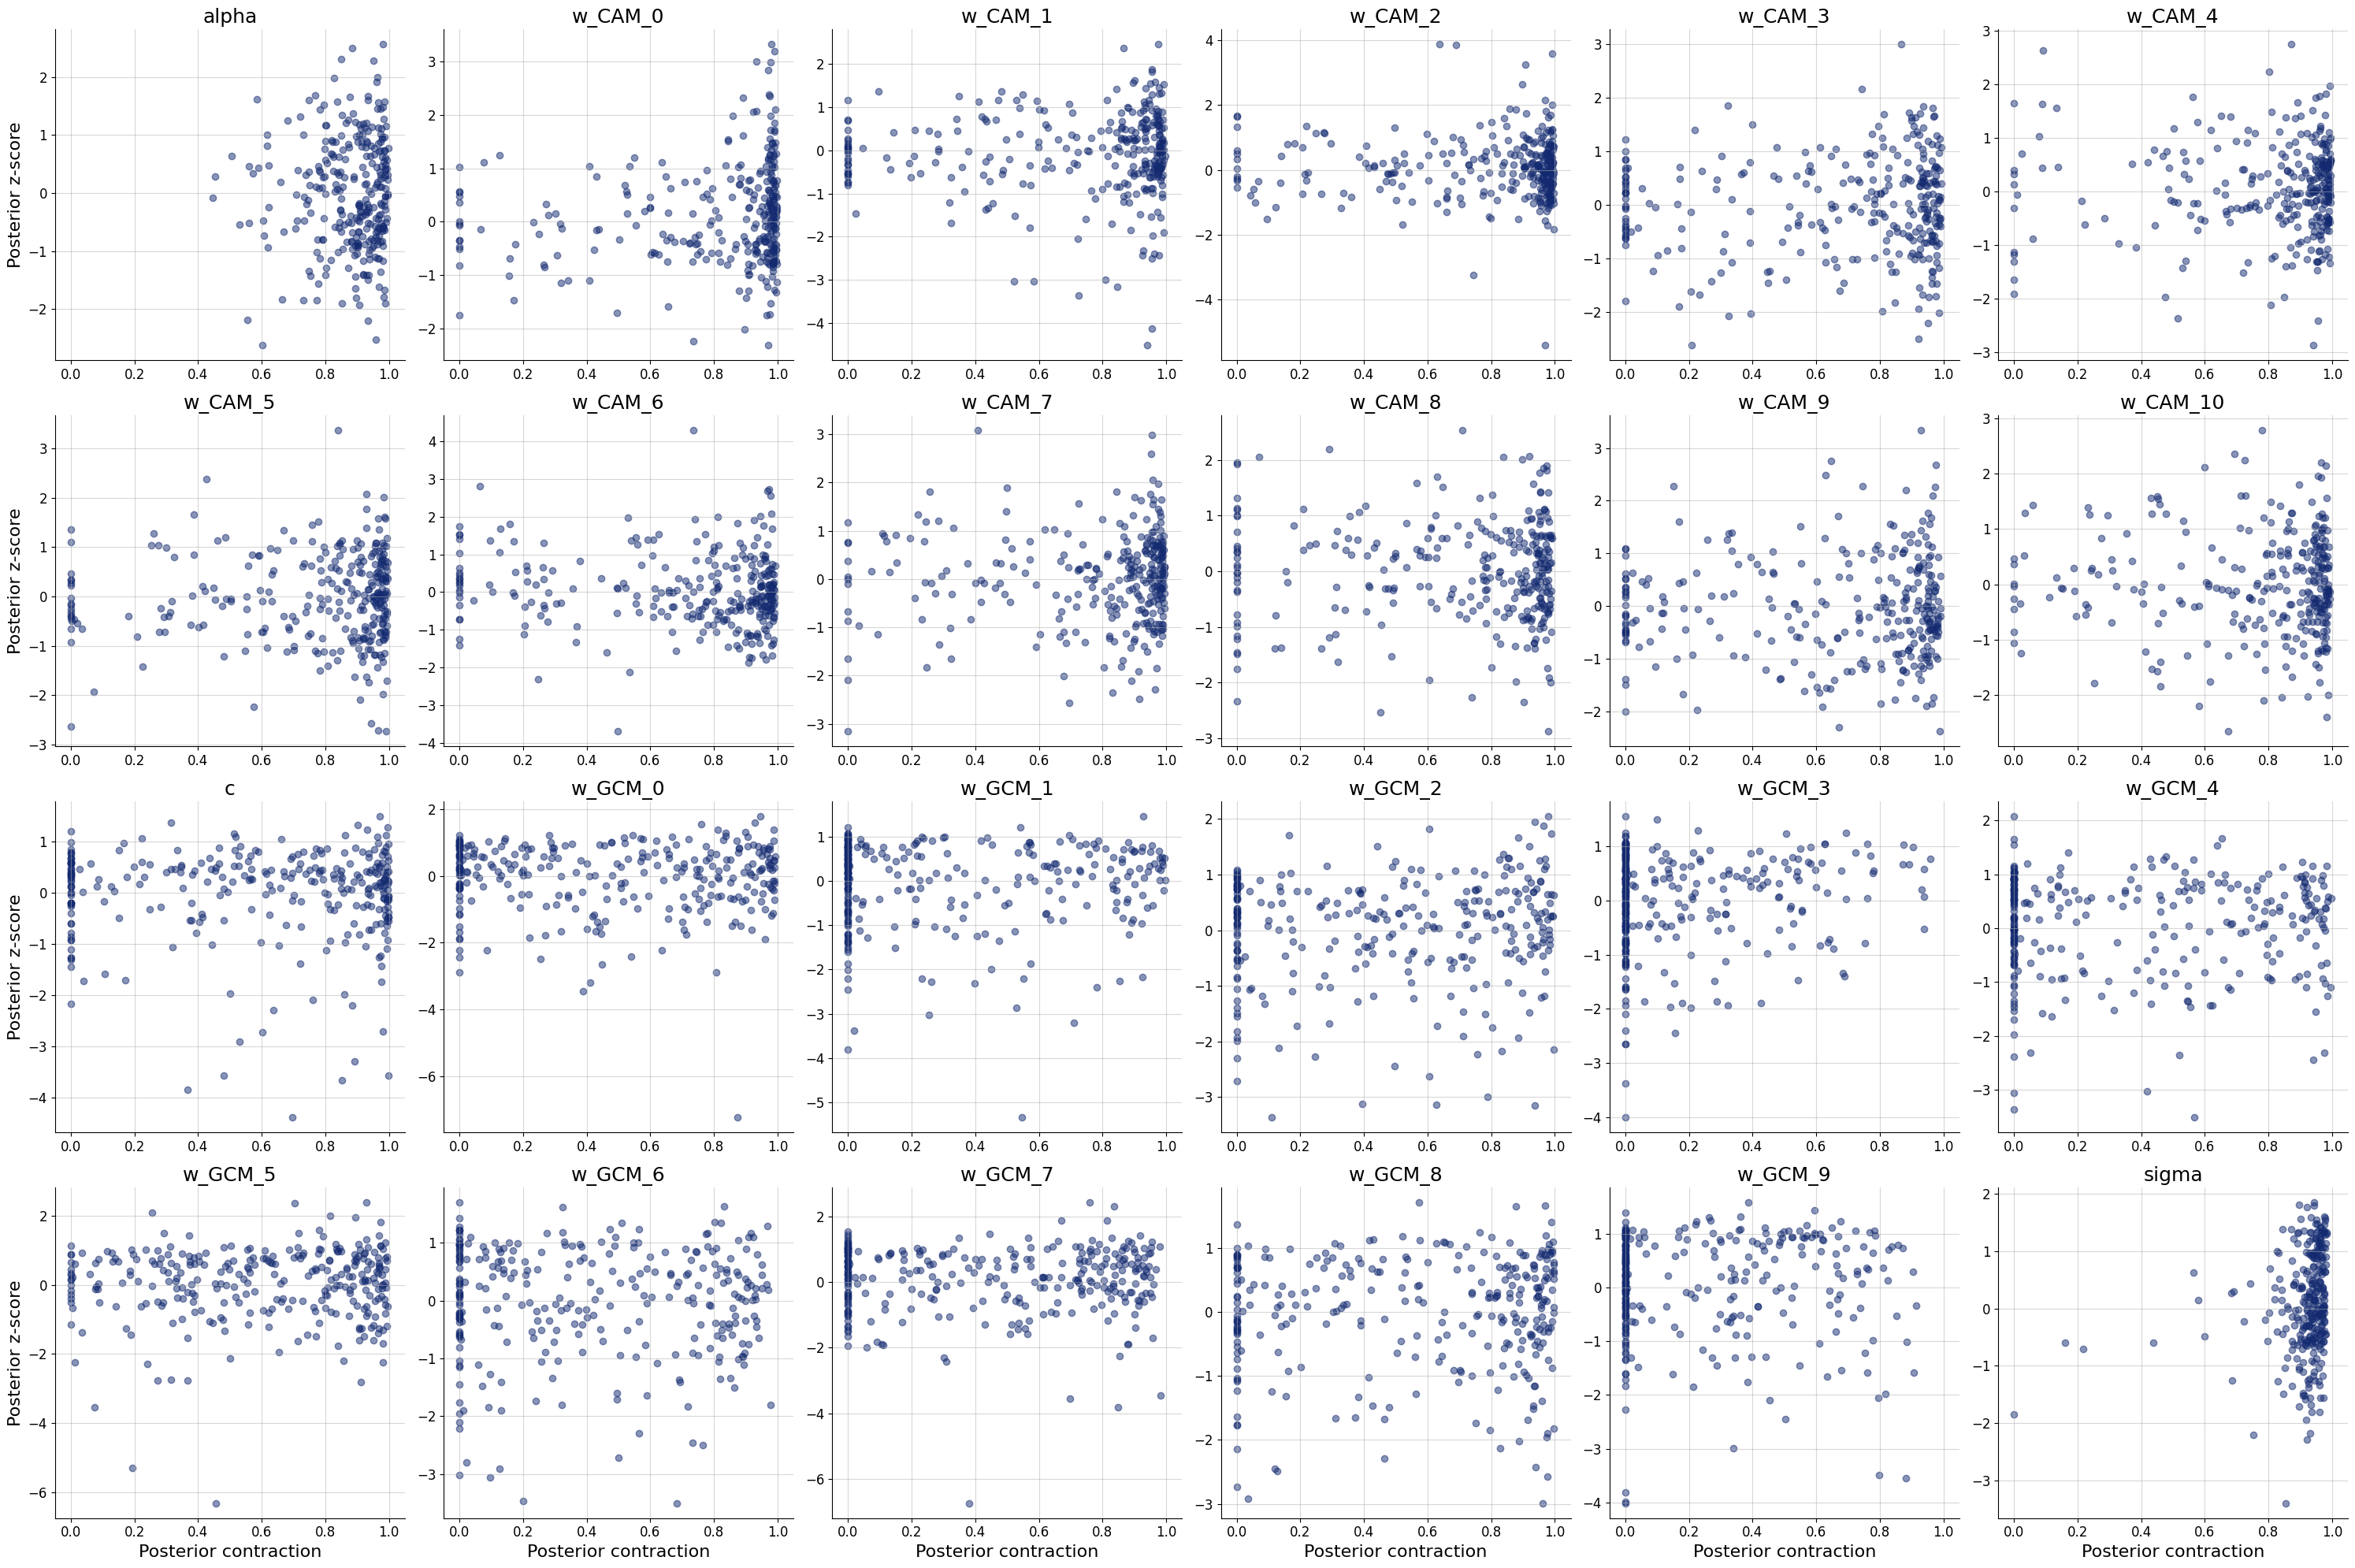

In [33]:
figures = workflow_RULEXJ.plot_default_diagnostics(
    test_data                  = 300,
    loss_kwargs                = {"figsize": (7, 4), "label_fontsize": 12},
    recovery_kwargs            = {"figsize": (12, 7), "label_fontsize": 12} 
)

## 2.4 Mapping Model (MAPP)

For the mapping model, the direction of the cues have to coded so that each cue (i.e., dimension) has a positive relationship with the criterion.

In [34]:
# Change cue direction and redefine exemplar and stimuli cues for the mapping model
all_mapp_cues  = mf.preprocess_cues(all_cues,all_crit)
ex_mapp_cues   = all_mapp_cues[ex_IDs-1,:]
mapp_cues      = all_mapp_cues[test_IDs-1,:]
dict_mapp_cues = {f"cue_{i}": mapp_cues[:, i] for i in range(mapp_cues.shape[1])}

In [35]:
def prior_MAPP(lower = 2, upper = 12, rate = rate):

    n_cats = fn.truncated_poisson_np(5, lower = lower, upper = upper)
    sigma  = rng.exponential(1/rate)
    
    return  dict(n_cats=n_cats[0], sigma=sigma)

In [36]:
def model_MAPP(n_cats, sigma, cues=mapp_cues,ex_cues=ex_mapp_cues, ex_crit=ex_crit, p=position_encodings):

    n_trials, _   =  cues.shape 

    # Make predictions based on the GCM model for each person
    pred_crit = mf.MAPP_experiment(n_cats,cues,ex_cues,ex_crit)

    # Simulate responses 
    x = fn.truncnorm_r(mean=pred_crit, sd=sigma, low=0, upp=10000, size=n_trials)
  

    return dict(x=x, p=p)

In [37]:
simulator_MAPP = bf.make_simulator([prior_MAPP, model_MAPP])

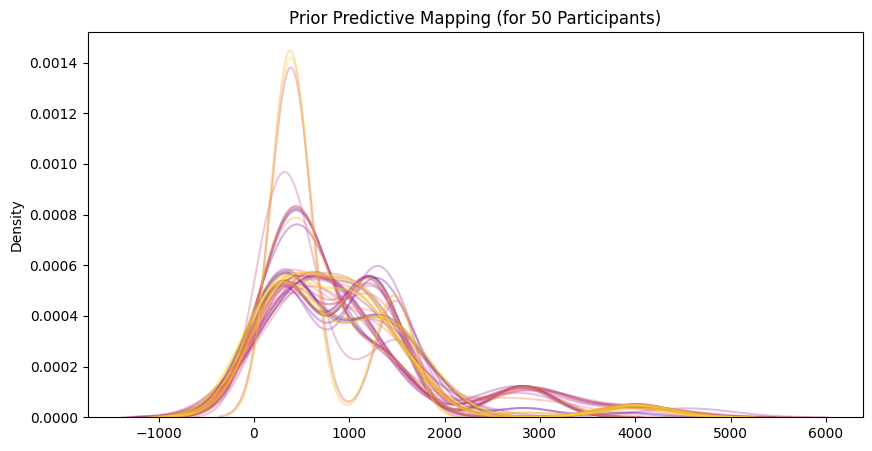

In [38]:
fig, ax = fn.plot_prior_predictives(simulator_MAPP, "Mapping")

### Estimation

In [39]:
adapter_MAPP = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .as_time_series(["x","p"])

    .constrain("sigma", lower=0)
    .constrain("n_cats", lower=0)
    
    
    .standardize()

    .concatenate(["n_cats", "sigma"], into="inference_variables")
    .concatenate(["x", "p"], into="summary_variables")
)

summary_network   = bf.networks.TimeSeriesNetwork(summary_dim=15)

inference_network = bf.networks.CouplingFlow()

workflow_MAPP = bf.BasicWorkflow(
    simulator         = simulator_MAPP,
    adapter           = adapter_MAPP,
    summary_network   = summary_network,
    inference_network = inference_network,
)


In [40]:
# %%time
# history = workflow_MAPP.fit_online(epochs=10, batch_size=32, num_batches_per_epoch=1000)

In [41]:
# Save model
#  workflow_MAPP.approximator.save("..\..\Results\Trained Networks\estimation_MAPP_MAMMALS.keras")
workflow_MAPP.approximator     = keras.saving.load_model("..\..\Results\Trained Networks\estimation_MAPP_MAMMALS.keras")

c:\Users\dizydorc\OneDrive\University\Project Github Repositories\Estimation processes in real-world domains\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 205 variables. 


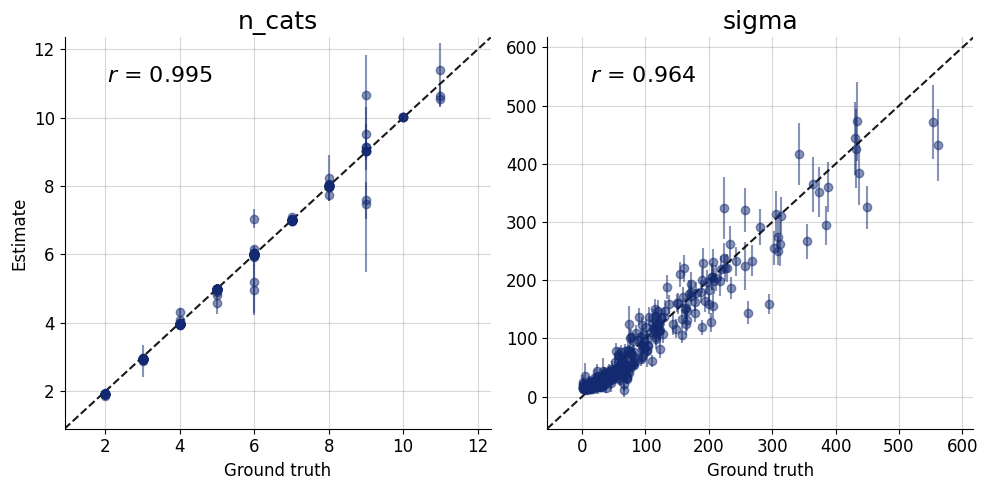

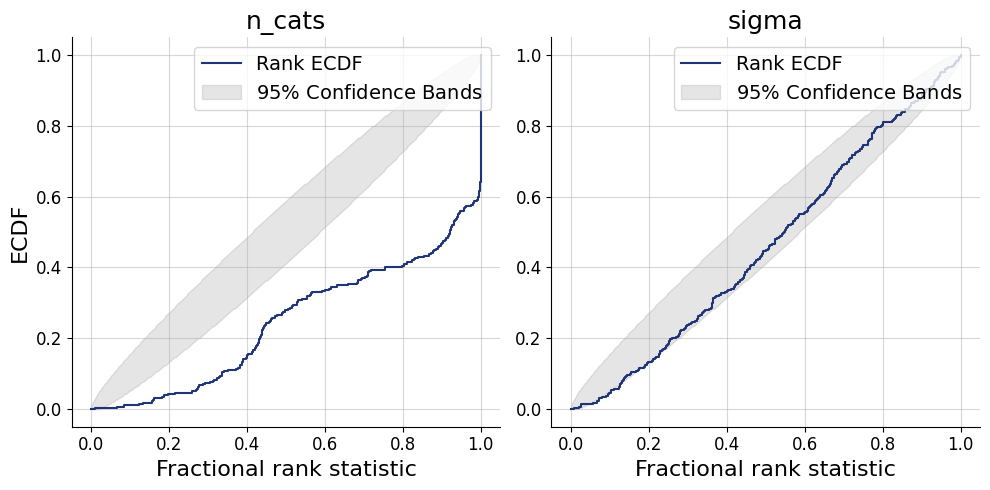

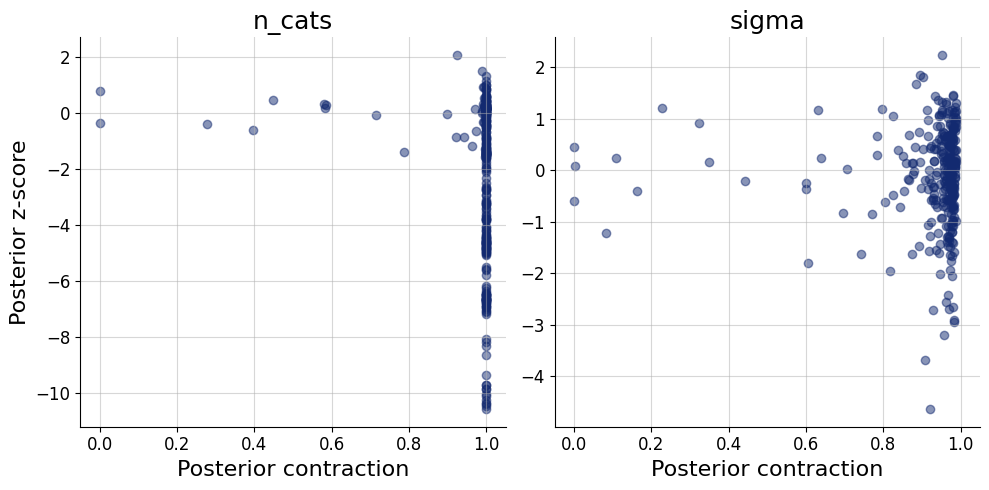

In [42]:
figures = workflow_MAPP.plot_default_diagnostics(
    test_data                  = 300,
    loss_kwargs                = {"figsize": (7, 4), "label_fontsize": 12},
    recovery_kwargs            = {"figsize": (10, 5), "label_fontsize": 12} 
)

# 3 Model Fitting per Participant

In [43]:
# Load trained networks

workflow_CAM.approximator     = keras.saving.load_model("..\..\Results\Trained Networks\estimation_CAM_MAMMALS.keras")
workflow_GCM.approximator     = keras.saving.load_model("..\..\Results\Trained Networks\estimation_GCM_MAMMALS.keras")
workflow_RULEXJ.approximator  = keras.saving.load_model("..\..\Results\Trained Networks\estimation_RULEXJ_MAMMALS.keras")
workflow_MAPP.approximator    = keras.saving.load_model("..\..\Results\Trained Networks\estimation_MAPP_MAMMALS.keras")

c:\Users\dizydorc\OneDrive\University\Project Github Repositories\Estimation processes in real-world domains\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 303 variables. 


In [44]:
# Load data

df = pd.read_csv('../../Data/data_analysis_mammals.csv', sep = ",")
df.head()

,ID_item,item,img,training,crit,chp46vl70814,apzvrxiaap22,dp0g9nbjr8wo,ch1i36lf3gb1,mrb0s0ckbda9,...,0xhc0yxm5czl,uh7i5dewrmic,wl5925o0j4iv,a3eokjk1z75r,tk04u7pmrsvp,s2edlrqnhaz8,2qewr80masfh,xhkz4vsry78k,rsulb3mqq6p4,u13d9hi208ge
0,1,Aoudad,01.png,0,335,2000,1500,1200,700,257,...,600,1350,750,2000,600,880,600,700,730,700
1,2,Brazilian tapir,02.png,0,1095,550,500,1200,600,321,...,800,802,560,720,400,456,590,700,1100,700
2,3,American bison,03.png,0,912,3000,2000,2500,360,875,...,1500,3520,1566,4000,1500,578,1500,1300,678,570
3,4,Giant anteater,04.png,0,1186,750,250,1500,500,432,...,500,450,550,550,400,450,900,1400,564,400
4,5,Ibex,05.png,0,797,700,2000,650,350,543,...,640,1256,720,720,2000,340,1500,800,1100,570


In [45]:
data            = df.to_numpy()
data            = np.float32(data[(test_IDs-1),5:])

n_trials, n_sub = data.shape

print("n_trials:", n_trials)
print("n_sub:"   , n_sub)


domain      = "Mammals"

n_trials: 68
n_sub: 48


Text(0.5, 1.0, 'Distribution of Participants Estimates')

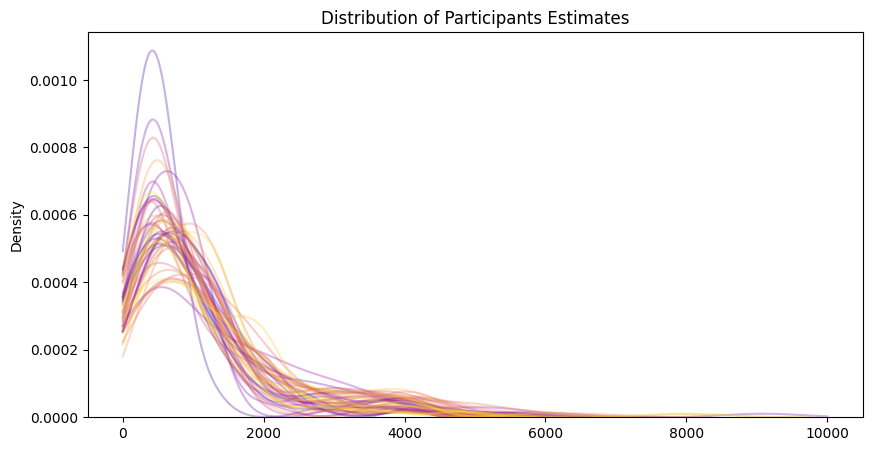

In [46]:
# Plot prior predictives
fig, axes = plt.subplots(figsize=(10, 5))
dataset_colors = sns.color_palette("plasma", n_sub).as_hex()

for dataset in range(n_sub):
    color = dataset_colors[dataset]

    sns.kdeplot(data[:,dataset].squeeze(), ax=axes, alpha=0.3, legend=False, color=color,clip=(0.0, 10000.0))
    

axes.set_title("Distribution of Participants Estimates")

## Estimate Parameters

In [47]:
num_samples = 10000

### CAM

In [48]:
pars   = np.array(["w[0]","w[1]","w[2]","w[3]","w[4]","w[5]","w[6]","w[7]","w[8]","w[9]","w[10]","sigma"])
n_pars = pars.shape[0]

In [49]:
CAM_post_summary = []

for i in range(n_sub):
    temp      = dict(x = data[:,i].reshape(1,n_trials), p=position_encodings)
    samples   = workflow_CAM.sample(num_samples=num_samples,conditions=temp)

    idata     = az.from_dict(posterior={"w": samples["w"],
                                        "sigma":  samples["sigma"]})

    summary      = az.summary(idata, var_names=["w","sigma"], hdi_prob=0.95, kind="stats").to_numpy()
    ests         = np.c_[summary, pars, np.repeat("CAM",n_pars) , np.repeat(i,n_pars), np.repeat(domain,n_pars)]
    CAM_post_summary.append(ests)

CAM_post_summary = np.array(CAM_post_summary)

In [50]:
CAM_post_summary = CAM_post_summary.reshape(n_sub * n_pars, 8)
df_CAM           = pd.DataFrame(CAM_post_summary, columns=["mean","sd","hdi_025","hdi_975","paramter","model","ID_ind","domain"])

### GCM

In [51]:
pars   = np.array(["c","w[1]","w[2]","w[3]","w[4]","w[5]","w[6]","w[7]","w[8]","w[9]","w[10]","sigma"])
n_pars = pars.shape[0]

In [52]:
GCM_post_summary = []

for i in range(n_sub):
    temp      = dict(x = data[:,i].reshape(1,n_trials), p=position_encodings)
    samples   = workflow_GCM.sample(num_samples=num_samples,conditions=temp)

    idata     = az.from_dict(posterior={"c": samples["c"],
                                        "w": samples["w"],
                                        "sigma":  samples["sigma"]})

    summary      = az.summary(idata, var_names=["c" ,"w","sigma"], hdi_prob=0.95, kind="stats").to_numpy() 
    ests         = np.c_[summary, pars, np.repeat("GCM",n_pars) , np.repeat(i,n_pars), np.repeat(domain,n_pars)]
    GCM_post_summary.append(ests)

GCM_post_summary = np.array(GCM_post_summary)

In [53]:
GCM_post_summary = GCM_post_summary.reshape(n_sub * n_pars, 8)
df_GCM           = pd.DataFrame(GCM_post_summary, columns=["mean","sd","hdi_025","hdi_975","paramter","model","ID_ind","domain"])

### RulEx-J

In [54]:
pars   = np.array(["alpha","w_CAM[0]","w_CAM[1]","w_CAM[2]","w_CAM[3]","w_CAM[4]","w_CAM[5]","w_CAM[6]","w_CAM[7]","w_CAM[8]","w_CAM[9]","w_CAM[10]",
                   "c","w_GCM[1]","w_GCM[2]","w_GCM[3]","w_GCM[4]","w_GCM[5]","w_GCM[6]","w_GCM[7]","w_GCM[8]","w_GCM[9]","w_GCM[10]","sigma"])
n_pars = pars.shape[0]

In [55]:
RulExJ_post_summary = []

for i in range(n_sub):
    temp      = dict(x = data[:,i].reshape(1,n_trials), p=position_encodings)
    samples   = workflow_RULEXJ.sample(num_samples=num_samples,conditions=temp)

    idata     = az.from_dict(posterior={"alpha": samples["alpha"],
                                        "w_CAM": samples["w_CAM"],
                                        "c": samples["c"],
                                        "w_GCM": samples["w_GCM"],
                                        "sigma":  samples["sigma"]})

    summary      = az.summary(idata, var_names=["alpha","w_CAM","c","w_GCM","sigma"], hdi_prob=0.95, kind="stats").to_numpy()
    ests         = np.c_[summary, pars, np.repeat("RULEXJ",n_pars) , np.repeat(i,n_pars), np.repeat(domain,n_pars)]
    RulExJ_post_summary.append(ests)

RulExJ_post_summary = np.array(RulExJ_post_summary)

In [56]:
RulExJ_post_summary = RulExJ_post_summary.reshape(n_sub * n_pars, 8)
df_RULEXJ           = pd.DataFrame(RulExJ_post_summary, columns=["mean","sd","hdi_025","hdi_975","paramter","model","ID_ind","domain"])

### Mapping

In [57]:
pars   = np.array(["n_cats","sigma"])
n_pars = pars.shape[0]

In [58]:
MAP_post_summary = []

for i in range(n_sub):
    temp      = dict(x = data[:,i].reshape(1,n_trials), p=position_encodings)
    samples   = workflow_MAPP.sample(num_samples=num_samples,conditions=temp)

    idata     = az.from_dict(posterior={"n_cats": samples["n_cats"],
                                        "sigma":  samples["sigma"]})

    summary      = az.summary(idata, var_names=["n_cats","sigma"], hdi_prob=0.95, kind="stats").to_numpy()
    
    ests         = np.c_[summary, pars, np.repeat("MAPP",n_pars) , np.repeat(i,n_pars), np.repeat(domain,n_pars)]
    MAP_post_summary.append(ests)

MAP_post_summary = np.array(MAP_post_summary)

In [59]:
MAP_post_summary = MAP_post_summary.reshape(n_sub * n_pars, 8)
df_MAPP          = pd.DataFrame(MAP_post_summary, columns=["mean","sd","hdi_025","hdi_975","paramter","model","ID_ind","domain"])

## Combine and save everything

In [60]:
df_combined = pd.concat([df_RULEXJ, df_CAM, df_GCM, df_MAPP], axis=0, ignore_index=True)
df_combined.to_csv("..\..\Results\Parameter Estimates\par_ests_MAMMALS_21082025.csv")